<a href="https://colab.research.google.com/github/imtisalrangrez/DeepLearning_Lab/blob/main/DL_week6(180).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# keras imports for the dataset and building our neural network
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten

from tensorflow.keras.utils import to_categorical

# to calculate accuracy
from sklearn.metrics import accuracy_score

# loading the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
#X_train and y_train are the training images and their labels, respectively, while X_test and y_test are the test images and labels.
# Reshapes the data so it has the shape (samples, height, width, channels).
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
#Converts the data type of the image data to float32 for better precision during training.
# #Divides the pixel values by 255 to normalize the images.
#This scales the values to the range [0, 1], which makes the training more stable and faster.
X_train /= 255
X_test /= 255

# one-hot encoding using keras' numpy-related utilities
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

#The labels (y_train, y_test) are converted to one-hot encoded format.
# building a linear stack of layers with the sequential model
model = Sequential()
# convolutional layer

model.add(Conv2D(25, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu', input_shape=(28,28,1)))

model.add(MaxPool2D(pool_size=(2,2)))

# flatten output of conv

model.add(Flatten())

# hidden layer

model.add(Dense(100, activation='relu'))

# output layer
model.add(Dense(10, activation='softmax'))

# compiling the sequential model
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# training the model for 10 epochs
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

Shape before one-hot encoding:  (60000,)
Shape after one-hot encoding:  (60000, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.8682 - loss: 0.4827 - val_accuracy: 0.9731 - val_loss: 0.0876
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9774 - loss: 0.0750 - val_accuracy: 0.9781 - val_loss: 0.0669
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9854 - loss: 0.0504 - val_accuracy: 0.9796 - val_loss: 0.0587
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9886 - loss: 0.0365 - val_accuracy: 0.9847 - val_loss: 0.0457
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9917 - loss: 0.0272 - val_accuracy: 0.9846 - val_loss: 0.0412
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9942 - loss: 0.0206 - val_accuracy: 0.9833 - val_loss: 0.0492
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 0.9841 - val_loss: 0.0503
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.9957 - loss: 0.0137 - 

In [ ]:
# Evaluating the model on the test set
test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


# Making predictions on the test set
y_pred = model.predict(X_test)

# Convert predictions from one-hot encoding back to class labels (argmax gives the index of the highest probability)
y_pred_classes = y_pred.argmax(axis=-1)

# Convert Y_test back to class labels (argmax gives the index of the highest probability)
y_test_classes = Y_test.argmax(axis=-1)

# Calculating accuracy using sklearn's accuracy_score
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy on test set:", accuracy)



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9827 - loss: 0.0585
Test loss: 0.04774877429008484
Test accuracy: 0.9861999750137329
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy on test set: 0.9862


In [ ]:
score = model.evaluate(X_test, Y_test, verbose=1)
print('loss=', score[0])
print('accuracy=', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9827 - loss: 0.0585
loss= 0.04774877429008484
accuracy= 0.9861999750137329


(50000, 32, 32, 3) (10000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.3810 - loss: 1.6761 - val_accuracy: 0.4951 - val_loss: 1.4080
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.5307 - loss: 1.3132 - val_accuracy: 0.5887 - val_loss: 1.1619
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.5858 - loss: 1.1698 - val_accuracy: 0.6077 - val_loss: 1.1126
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.6215 - loss: 1.0737 - val_accuracy: 0.6325 - val_loss: 1.0361
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.6492 - loss: 1.0021 - val_accuracy: 0.6661 - val_loss: 0.9433
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.6723 - loss: 0.9421 - val_accuracy: 0.6894 - val_loss: 0.8818
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.6905 - loss: 0.8850 - val_accuracy: 0.6680 - val_loss: 0.9521
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 100ms/step - accuracy: 0.7020 - loss: 0.8555 -

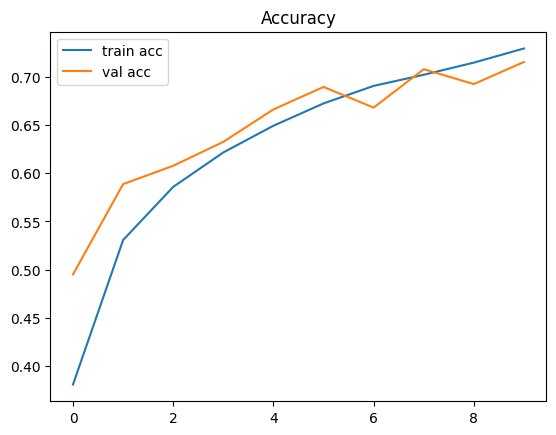

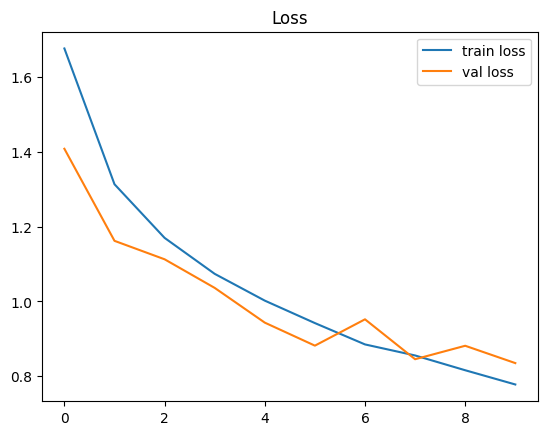

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize (VERY IMPORTANT)
x_train, x_test = x_train / 255.0, x_test / 255.0

print(x_train.shape, x_test.shape)

def build_model(num_filters=32, kernel_size=(3,3), dropout_rate=0.5, learning_rate=0.001):
    model = models.Sequential()

    # Convolutional Layers
    model.add(layers.Conv2D(num_filters, kernel_size, activation='relu', input_shape=(32,32,3)))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(num_filters*2, kernel_size, activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(num_filters*2, kernel_size, activation='relu'))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
#Lower learning rate → slower but stable convergence
#High learning rate → faster but may overshoot
#Dropout reduces overfitting
#Increasing filters improves feature extraction but increases training time
#Smaller batch size → better generalization but noisy updates

configs = [
    {"lr": 0.001, "batch": 64, "dropout": 0.5},
    {"lr": 0.0005, "batch": 64, "dropout": 0.3},
    {"lr": 0.0001, "batch": 32, "dropout": 0.5},
]

results = []

for config in configs:
    print("Testing:", config)

    model = build_model(
        learning_rate=config["lr"],
        dropout_rate=config["dropout"]
    )

    history = model.fit(
        x_train, y_train,
        epochs=8,
        batch_size=config["batch"],
        validation_data=(x_test, y_test),
        verbose=0
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append((config, test_acc))

# Print results
for r in results:
    print(r)

#ON FASHION_MNIST
Learning Rate (The most sensitive parameter):LR = 0.001 (Standard Default): Usually yields the best and most stable results with the Adam optimizer (hitting ~90-91% accuracy). It learns fast enough without jumping past the optimal weights.LR = 0.01 (Fast LR): This is generally too high for Adam. The model takes steps that are too aggressive, causing the accuracy to fluctuate wildly and often resulting in the worst performance in the test block.Dropout Rate:Dropout = 0.5: Often a bit too harsh for a shallow CNN on simple $28 \times 28$ images. It turns off 50% of the neurons, which can actually slow down learning too much.Dropout = 0.2 or 0.3: This is the sweet spot. It provides just enough regularization to prevent overfitting without starving the network of the visual features it needs to classify the clothing.Batch Size:Batch = 32: Updates the weights very frequently. It generalizes slightly better to unseen data but takes a bit longer to process each epoch.Batch = 128: Processes data faster but updates the weights less often. It results in a smoother, less "noisy" loss curve, but sometimes gets stuck in local minimums, resulting in a slightly lower final accuracy than batch size 32.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Input
import numpy as np

# ---------------------------------------------------------
# 1. Load and Preprocess CIFAR-10
# ---------------------------------------------------------
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
# Shape is already (Batch, 32, 32, 3) — no reshape needed for channels
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# CIFAR-10 class names for reference
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"Training data shape : {x_train.shape}")   # (50000, 32, 32, 3)
print(f"Test data shape     : {x_test.shape}")     # (10000, 32, 32, 3)
print(f"Classes             : {class_names}")

# ---------------------------------------------------------
# 2. Reusable CNN Model Builder
# ---------------------------------------------------------
def build_cnn(num_filters=64, dropout_rate=0.5, learning_rate=0.001):
    """
    Three conv-pool blocks to handle CIFAR-10's 32x32 RGB images.
    Starts with num_filters and doubles each block.
    """
    model = models.Sequential([
        # Input: 32x32 RGB
        Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),                          # → 16x16

        # Block 2
        layers.Conv2D(num_filters * 2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),                          # → 8x8

        # Block 3  ← extra block vs. Fashion-MNIST version
        layers.Conv2D(num_filters * 4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),                          # → 4x4

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')               # 10 CIFAR-10 classes
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ---------------------------------------------------------
# 3. Hyperparameter Grid Search
# ---------------------------------------------------------
configs = [
    {"lr": 0.001,  "batch": 32,  "dropout": 0.3, "name": "Standard Default"},
    {"lr": 0.0005, "batch": 64,  "dropout": 0.5, "name": "Slow & Steady"},
    {"lr": 0.01,   "batch": 64,  "dropout": 0.3, "name": "Fast LR"},
    {"lr": 0.001,  "batch": 128, "dropout": 0.2, "name": "Large Batch"}
]

results = []

print("\n--- Starting Parameter Search ---")
for config in configs:
    print(f"\nTraining Config: {config['name']} → LR: {config['lr']}, "
          f"Batch: {config['batch']}, Dropout: {config['dropout']}")

    tf.random.set_seed(42)

    model = build_cnn(
        learning_rate=config["lr"],
        dropout_rate=config["dropout"]
    )

    history = model.fit(
        x_train, y_train,
        epochs=8,
        batch_size=config["batch"],
        validation_data=(x_test, y_test),
        verbose=0
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append((config['name'], test_acc))
    print(f"Result → Test Accuracy: {test_acc:.4f}")

# ---------------------------------------------------------
# 4. Final Summary
# ---------------------------------------------------------
print("\n" + "=" * 40)
print(f"{'Configuration':<20} | {'Test Accuracy'}")
print("=" * 40)
results.sort(key=lambda x: x[1], reverse=True)
for name, acc in results:
    print(f"{name:<20} | {acc:.4f}")
print("=" * 40)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape : (50000, 32, 32, 3)
Test data shape     : (10000, 32, 32, 3)
Classes             : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

--- Starting Parameter Search ---

Training Config: Standard Default → LR: 0.001, Batch: 32, Dropout: 0.3
Result → Test Accuracy: 0.7395

Training Config: Slow & Steady → LR: 0.0005, Batch: 64, Dropout: 0.5
Result → Test Accuracy: 0.7486

Training Config: Fast LR → LR: 0.01, Batch: 64, Dropout: 0.3
Result → Test Accuracy: 0.1000

Training Config: Large Batch → LR: 0.001, Batch: 128, Dropout: 0.2
Result → Test Accuracy: 0.7365

Configuration        | Test Accuracy
Slow & Steady        | 0.7486
Standard Default     | 0.7395
Large Batch          | 0.7365
Fast LR              | 0.1000
